In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!apt-get install -y aria2
!pip install requests beautifulsoup4

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libaria2-0 libc-ares2
The following NEW packages will be installed:
  aria2 libaria2-0 libc-ares2
0 upgraded, 3 newly installed, 0 to remove and 51 not upgraded.
Need to get 1,513 kB of archives.
After this operation, 5,441 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libc-ares2 amd64 1.18.1-1ubuntu0.22.04.3 [45.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libaria2-0 amd64 1.36.0-1 [1,086 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 aria2 amd64 1.36.0-1 [381 kB]
Fetched 1,513 kB in 0s (23.9 MB/s)
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubunt

In [3]:
import requests
from bs4 import BeautifulSoup

amc_urls = []
for i in range(1, 145):
    subj = str(i).zfill(2)
    url = f"http://mocap.cs.cmu.edu/subjects/{subj}/"
    r = requests.get(url)
    soup = BeautifulSoup(r.text, "html.parser")
    for link in soup.find_all("a"):
        href = link.get("href", "")
        if href.endswith(".amc"):
            amc_urls.append(f"http://mocap.cs.cmu.edu/subjects/{subj}/{href}")

print(f"Total .amc files found: {len(amc_urls)}")

# Download all in parallel
with open("amc_urls.txt", "w") as f:
    f.write("\n".join(amc_urls))

!aria2c -i amc_urls.txt -j 16 -x 4 --dir="./amc_files"

Streaming output truncated to the last 5000 lines.

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_16.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_17.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_18.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_19.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_20.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_22.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_21.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/32_11.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_23.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_26.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_24.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/35_25.amc

05/20 03:55:08 [NOTICE] Download complete: ./amc_files/31_14.amc

05/20 03:55:09 [NOTICE] Download complete: ./amc_files/35_28.amc

05/20 03:55:09 [NOTICE] 

In [4]:
#parse the amc file
def parse_mocap(filepath: str) -> torch.Tensor:
    frames = []
    current = []

    for line in open(filepath):
        line = line.strip()
        if not line or line.startswith(":") or line.startswith("#"):
            continue
        if line.isdigit():
            if current:
                frames.append(current)
            current = []
        else:
            parts = line.split()
            current.extend(float(v) for v in parts[1:])

    if current:
        frames.append(current)

    max_len = max(len(f) for f in frames)
    frames = [f + [0.0]*(max_len-len(f)) for f in frames]

    return torch.tensor(frames) #returns a tensor of shape (n_frames, action_dim)


In [9]:
from multiprocessing import Pool
from pathlib import Path
import torch

amc_files = sorted(Path("./amc_files").glob("*.amc"))

def safe_parse(filepath):
    try:
        tensor = parse_mocap(str(filepath))
        subject = filepath.name.split("_")[0]  # "01" from "01_02.amc"
        return (subject, tensor)
    except Exception as e:
        print(f"Skipped {filepath.name}: {e}")
        return None

with Pool() as pool:
    results = pool.map(safe_parse, amc_files)
results = [r for r in results if r is not None]

# Group clips by subject
from collections import defaultdict
subject_clips = defaultdict(list)
for subject, tensor in results:
    subject_clips[subject].append(tensor)

subjects = list(subject_clips.keys())

# 80/10/10 on subjects
n = len(subjects)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

train_subjects = subjects[:n_train]
val_subjects   = subjects[n_train:n_train + n_val]
test_subjects  = subjects[n_train + n_val:]

train = torch.cat([t for s in train_subjects for t in subject_clips[s]], dim=0)
val   = torch.cat([t for s in val_subjects   for t in subject_clips[s]], dim=0)
test  = torch.cat([t for s in test_subjects  for t in subject_clips[s]], dim=0)

print(f"Subjects — Train: {len(train_subjects)} | Val: {len(val_subjects)} | Test: {len(test_subjects)}")
print(f"Shapes   — Train: {train.shape} | Val: {val.shape} | Test: {test.shape}")

torch.save(train, "/content/drive/MyDrive/mocap_train_tensor_v2.pt")
torch.save(val,   "/content/drive/MyDrive/mocap_val_tensor_v2.pt")
torch.save(test,  "/content/drive/MyDrive/mocap_test_tensor_v2.pt")

Subjects — Train: 88 | Val: 11 | Test: 12
Shapes   — Train: torch.Size([3288377, 62]) | Val: torch.Size([481390, 62]) | Test: torch.Size([436039, 62])


In [10]:
print(train_subjects)
print(val_subjects)
print(test_subjects)

['01', '02', '03', '05', '06', '07', '08', '09', '102', '103', '104', '105', '106', '107', '108', '10', '111', '113', '114', '115', '118', '11', '120', '122', '123', '124', '125', '126', '127', '128', '12', '131', '132', '133', '134', '135', '136', '137', '138', '139', '13', '140', '141', '142', '143', '144', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '45', '46', '47', '49', '54', '55', '56', '60', '61', '62', '63', '64']
['69', '70', '73', '74', '75', '76', '77', '78', '79', '80', '81']
['82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '93', '94']


In [12]:
#get the datasets
from google.colab import drive
drive.mount('/content/drive')

train_set = torch.load("/content/drive/MyDrive/mocap_train_tensor_v2.pt")
val_set   = torch.load("/content/drive/MyDrive/mocap_val_tensor_v2.pt")
test_set  = torch.load("/content/drive/MyDrive/mocap_test_tensor_v2.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_set = train_set.to(device)
val_set   = val_set.to(device)
test_set  = test_set.to(device)

print(train_set.shape, val_set.shape, test_set.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch.Size([3288377, 62]) torch.Size([481390, 62]) torch.Size([436039, 62])


In [13]:
#normalise the dataset
mean = train_set.mean(dim=0)
std  = train_set.std(dim=0) + 1e-8
train_set = (train_set-mean)/std
val_set = (val_set-mean)/std
test_set = (test_set-mean)/std

In [15]:
#hyperparameters
action_dim  = 62
d_model     = 256
num_heads   = 8
num_layers  = 10
max_seq     = 64 #sliding window
_batch_size  = 1024
_lr          = 1e-4

#encoder
class ActionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(action_dim, d_model)

    def forward(self, x):
        # x shape: (batch, seq, action_dim)
        return self.proj(x)
        # output shape: (batch, seq, d_model)


#transformer block
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

    def forward(self, x):
        normed = self.norm1(x)
        T = x.shape[1]
        mask = torch.nn.Transformer.generate_square_subsequent_mask(T).to(device)
        x = x + self.attn(normed, normed, normed, attn_mask=mask, is_causal=True)[0]
        x = x + self.ffn(self.norm2(x))

        return x

#decoder
class ActionDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(d_model, action_dim)

    def forward(self, x):
        # x shape: (batch, seq, d_model)
        return self.proj(x)
        # output shape: (batch, seq, action_dim)


#full unimodal model
class Mars(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ActionEncoder()
        self.pos_emb = nn.Embedding(max_seq, d_model)
        self.blocks  = nn.ModuleList([TransformerBlock() for _ in range(num_layers)])
        self.decoder = ActionDecoder()

    def forward(self, x):
        # x shape: (batch, seq, action_dim)
        x = self.encoder(x)
        positions = torch.arange(x.shape[1], device=x.device)
        x = x + self.pos_emb(positions)
        for block in self.blocks:
            x = block(x)
        # decode last token, that's the next frame prediction
        x = self.decoder(x[:, -1, :])
        # output shape: (batch, action_dim)
        return x

model = Mars().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=_lr)
loss_fn = nn.MSELoss()

In [19]:
#lets train
def train_step(data, batch_size=_batch_size):
    max_start = data.shape[0] - max_seq - 1
    starts = torch.randint(0, max_start, (batch_size,))
    input  = torch.stack([data[s : s + max_seq] for s in starts])
    target = torch.stack([data[s + max_seq] for s in starts])
    pred   = model(input)
    loss   = loss_fn(pred, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def train(data, val_data, n_steps=100):
    losses, val_losses = [], []
    for step in range(n_steps):
        loss = train_step(data)
        losses.append(loss)
        if step % 50 == 0:
            val_loss = test(val_set)
            val_losses.append((step, val_loss))
            print(f"step {step:6d}  train {loss:.6f}  val {val_loss:.6f}")
    return losses, val_losses

losses, val_losses = train(train_set, val_set, n_steps=1000)

step      0  train 1.122821  val 0.800423
step     50  train 0.321034  val 0.101366
step    100  train 0.058990  val 0.052087
step    150  train 0.084807  val 0.019000
step    200  train 0.027795  val 0.049141
step    250  train 0.020387  val 0.019574
step    300  train 0.013301  val 0.034430
step    350  train 0.020025  val 0.018806
step    400  train 0.012405  val 0.011749
step    450  train 0.009804  val 0.013263
step    500  train 0.009175  val 0.009442
step    550  train 0.011221  val 0.009743
step    600  train 0.006061  val 0.010831
step    650  train 0.051357  val 0.021614
step    700  train 0.007790  val 0.008033
step    750  train 0.006928  val 0.010939
step    800  train 0.007332  val 0.012131
step    850  train 0.005180  val 0.006423
step    900  train 0.007112  val 0.004956
step    950  train 0.004810  val 0.005787


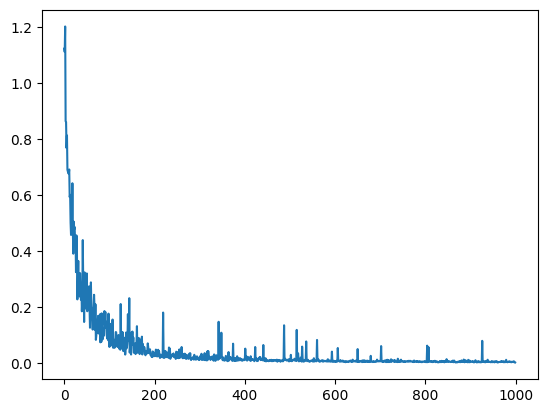

In [20]:
plt.plot(losses)

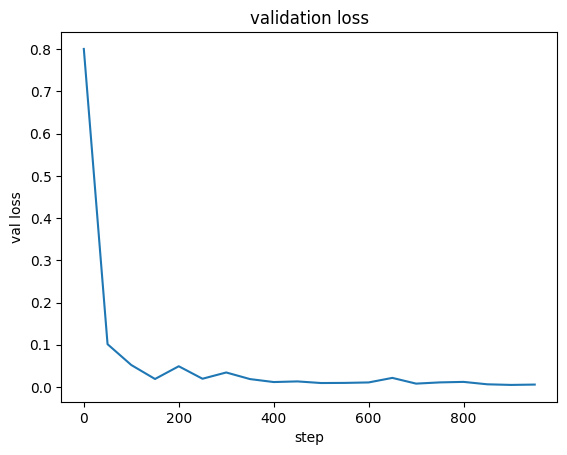

In [21]:
steps = [x[0] for x in val_losses]
vals  = [x[1] for x in val_losses]
plt.plot(steps, vals)
plt.xlabel('step')
plt.ylabel('val loss')
plt.title('validation loss')
plt.show()

In [18]:
#test
def test(seq, n_windows=500):
    model.eval()
    losses = []
    max_start = seq.shape[0] - max_seq - 1
    with torch.no_grad():
        for _ in range(n_windows):
            s = torch.randint(0, max_start, (1,)).item()
            input  = seq[s : s + max_seq].unsqueeze(0)
            target = seq[s + max_seq].unsqueeze(0)
            pred   = model(input)
            loss   = loss_fn(pred, target)
            losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

In [22]:
print(f"test loss: {test(test_set, n_windows=500)}")

test loss: 0.045792804836994036


In [23]:
torch.save(model.state_dict(), '/content/drive/MyDrive/mars_v6.pt')

In [ ]:
#real test
cartwheels        = (parse_mocap("/content/drive/MyDrive/test_datasets/cartwheels.amc ").to(device) - mean) / std
kicking           = (parse_mocap("/content/drive/MyDrive/test_datasets/kicking.amc ").to(device) - mean) / std
punching          = (parse_mocap("/content/drive/MyDrive/test_datasets/punching.amc").to(device) - mean) / std
range_of_motion   = (parse_mocap("/content/drive/MyDrive/test_datasets/range_of_motion.amc").to(device) - mean) / std
run_to_stop       = (parse_mocap("/content/drive/MyDrive/test_datasets/run_to_stop.amc").to(device) - mean) / std
walk_n_pickup     = (parse_mocap("/content/drive/MyDrive/test_datasets/walk_n_pickup.amc ").to(device) - mean) / std
walk_n_stepover   = (parse_mocap("/content/drive/MyDrive/test_datasets/walk_n_stepover.amc ").to(device) - mean) / std
waving            = (parse_mocap("/content/drive/MyDrive/test_datasets/waving.amc").to(device) - mean) / std
chicken_dance     = (parse_mocap("/content/drive/MyDrive/test_datasets/chicken_dance.amc ").to(device) - mean) / std

In [24]:
#ultimate test
backflip                  = (parse_mocap("/content/drive/MyDrive/ultimate_test/backflip.amc").to(device) - mean) / std
bounceshootdribblebasketball = (parse_mocap("/content/drive/MyDrive/ultimate_test/bounceshootdribblebasketball.amc").to(device) - mean) / std
carefulwalklookingaround  = (parse_mocap("/content/drive/MyDrive/ultimate_test/carefulwalklookingaround.amc").to(device) - mean) / std
fancyfootwork             = (parse_mocap("/content/drive/MyDrive/ultimate_test/fancyfootwork.amc").to(device) - mean) / std
hop_forward               = (parse_mocap("/content/drive/MyDrive/ultimate_test/hop_forward.amc").to(device) - mean) / std
indian_dance              = (parse_mocap("/content/drive/MyDrive/ultimate_test/indian_dance.amc").to(device) - mean) / std
sadwalk                   = (parse_mocap("/content/drive/MyDrive/ultimate_test/sadwalk.amc").to(device) - mean) / std

In [25]:
import torch

model = Mars().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/mars_v6.pt'))

<All keys matched successfully>

In [ ]:
print(f"cartwheels:        {test(cartwheels,        n_windows=500)}")
print(f"chicken_dance:     {test(chicken_dance,     n_windows=500)}")
print(f"kicking:           {test(kicking,           n_windows=500)}")
print(f"punching:          {test(punching,          n_windows=500)}")
print(f"range_of_motion:   {test(range_of_motion,   n_windows=500)}")
print(f"run_to_stop:       {test(run_to_stop,       n_windows=500)}")
print(f"walk_n_pickup:     {test(walk_n_pickup,     n_windows=500)}")
print(f"walk_n_stepover:   {test(walk_n_stepover,   n_windows=500)}")
print(f"waving:            {test(waving,            n_windows=500)}")

cartwheels:        0.14415358002029824
chicken_dance:     0.0029490151579957455
kicking:           0.0025335993624757977
punching:          0.0032032455208245666
range_of_motion:   0.08312530925963074
run_to_stop:       0.003093965017935261
walk_n_pickup:     0.0020897496169200165
walk_n_stepover:   0.0019588632937520742
waving:            0.0017569600115530193


In [26]:
print(f"backflip:                     {test(backflip,                     n_windows=500)}")
print(f"bounceshootdribblebasketball: {test(bounceshootdribblebasketball, n_windows=500)}")
print(f"carefulwalklookingaround:     {test(carefulwalklookingaround,     n_windows=500)}")
print(f"fancyfootwork:                {test(fancyfootwork,                n_windows=500)}")
print(f"hop_forward:                  {test(hop_forward,                  n_windows=500)}")
print(f"indian_dance:                 {test(indian_dance,                 n_windows=500)}")
print(f"sadwalk:                      {test(sadwalk,                      n_windows=500)}")

backflip:                     0.11358952827402391
bounceshootdribblebasketball: 0.002079526431043632
carefulwalklookingaround:     0.0021087788582080974
fancyfootwork:                0.034307651102310044
hop_forward:                  0.003679513921029866
indian_dance:                 0.22670597924059258
sadwalk:                      0.00264278366882354
